## Imports

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import os
import tqdm

## Data loading

In [ ]:
# Benchmark images from Udacity's Self-Driving Car Nanodegree Lane Detection dataset
images_urls = {
    "highway_1.jpg": "https://raw.githubusercontent.com/udacity/CarND-LaneLines-P1/master/test_images/solidYellowLeft.jpg",
    "highway_2.jpg": "https://raw.githubusercontent.com/udacity/CarND-LaneLines-P1/master/test_images/solidWhiteRight.jpg",
    "highway_3.jpg": "https://raw.githubusercontent.com/udacity/CarND-LaneLines-P1/master/test_images/solidYellowCurve.jpg",
}

# Define a User-Agent header to prevent 403 blocks from GitHub's CDN
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'
}

print("Starting downloads...\n")

for filename, url in images_urls.items():
    try:
        # Create a request object with the headers
        req = urllib.request.Request(url, headers=headers)

        # Open the URL and write the binary data to your local directory
        with urllib.request.urlopen(req) as response:
            with open(filename, 'wb') as out_file:
                out_file.write(response.read())
        print(f"✓ Downloaded: {filename}")

    except Exception as e:
        print(f"✗ Error downloading {filename}: {e}")

print("\nAll lane detection images ready ✓")

Starting downloads...

✓ Downloaded: highway_1.jpg
✓ Downloaded: highway_2.jpg
✓ Downloaded: highway_3.jpg

All lane detection images ready ✓


## Visualizing raw data

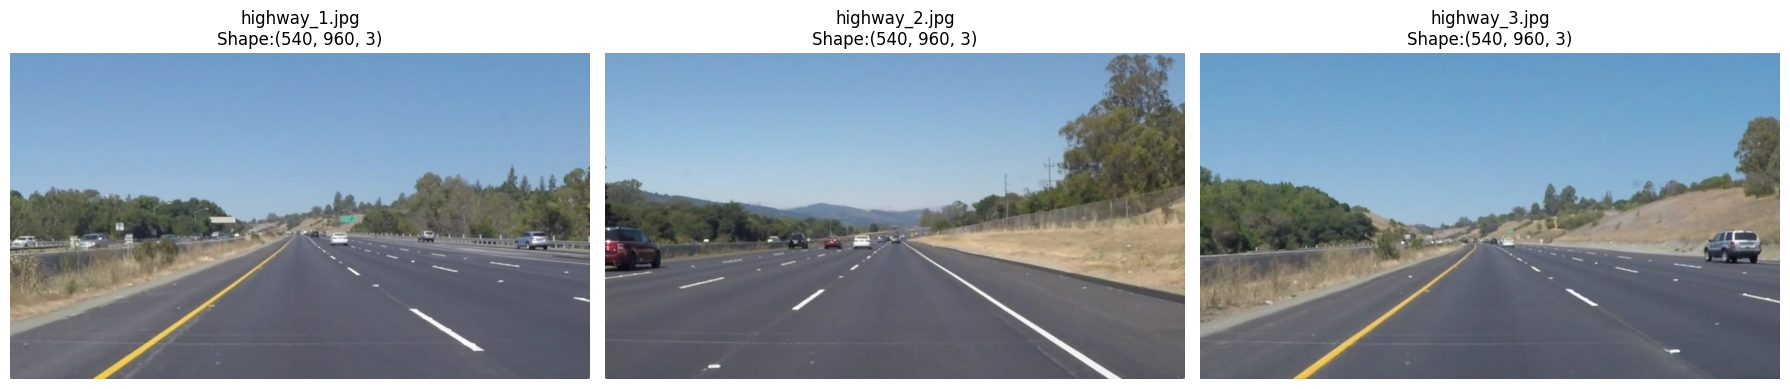

In [ ]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

filenames = images_urls.keys()

for ax, filename in zip(axes, filenames):
  img = cv2.imread(filename)
  # OpenCV reads images in BGR format by default, convert to RGB for matplotlib
  img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  ax.imshow(img_rgb)
  ax.set_title(f"{filename}\nShape:{img.shape}")
  ax.axis("off")

plt.tight_layout()
plt.show()

## Color Space Conversion (RGB, Grayscale, HLS, HSV)

Before edge detection, we convert the image to different color spaces. This helps in certain situations:

- **Grayscale**: Simplest form, just intensity values (0-255). Reduces 3 channels to 1.
- **HLS (Hue, Lightness, Saturation)**: Useful for detecting white lanes (high Lightness)
- **HSV (Hue, Saturation, Value)**: Good for detecting colored lanes like yellow

For lane detection, HLS is particularly useful because:
- White lanes have HIGH lightness (L channel)
- Yellow lanes have specific hue values and HIGH saturation

Let's see how the image looks in different color spaces:

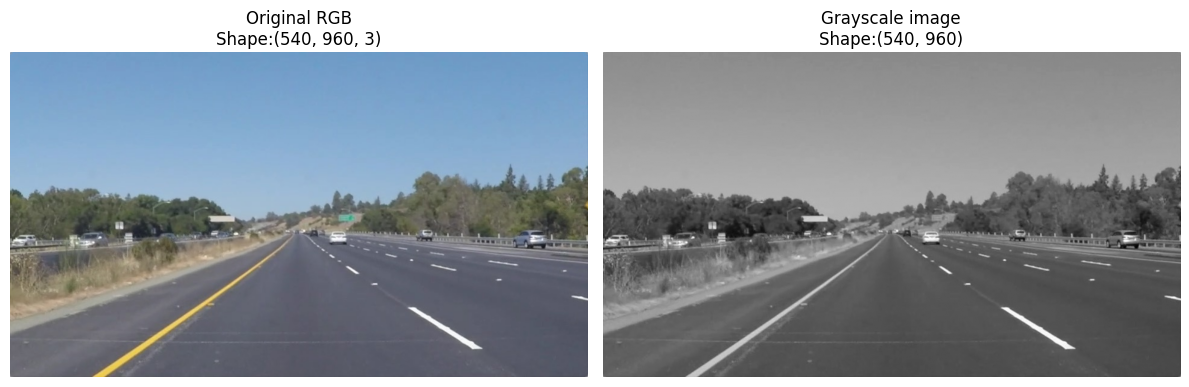

In [ ]:
# Load test image
img = cv2.imread("highway_1.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert to different color spaces
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
hls = cv2.cvtColor(img, cv2.COLOR_BGR2HLS)  # Hue, Lightness, Saturation
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)  # Hue, Saturation, Value

# Extract individual channels from HLS
h_channel = hls[:, :, 0]  # Hue
l_channel = hls[:, :, 1]  # Lightness - good for white lanes!
s_channel = hls[:, :, 2]  # Saturation - good for colored lanes

# Visualize all color spaces
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Row 1: Original and basic conversions
axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title('Original (RGB)')

axes[0, 1].imshow(gray, cmap='gray')
axes[0, 1].set_title('Grayscale')

axes[0, 2].imshow(hls)
axes[0, 2].set_title('HLS Color Space')

axes[0, 3].imshow(hsv)
axes[0, 3].set_title('HSV Color Space')

# Row 2: Individual HLS channels
axes[1, 0].imshow(h_channel, cmap='gray')
axes[1, 0].set_title('HLS - Hue Channel')

axes[1, 1].imshow(l_channel, cmap='gray')
axes[1, 1].set_title('HLS - Lightness Channel\n(white lanes visible!)')

axes[1, 2].imshow(s_channel, cmap='gray')
axes[1, 2].set_title('HLS - Saturation Channel')

# Threshold the L channel to isolate white lanes
l_thresh = cv2.threshold(l_channel, 200, 255, cv2.THRESH_BINARY)[1]
axes[1, 3].imshow(l_thresh, cmap='gray')
axes[1, 3].set_title('L Channel Thresholded\n(white lanes isolated)')

for ax in axes.flatten():
    ax.axis('off')

plt.suptitle('Color Space Conversions for Lane Detection', fontsize=14)
plt.tight_layout()
plt.show()

print('Notice how the Lightness channel clearly shows the white lane markings!')
print('This is why HLS conversion is useful for lane detection.')

## Gaussian Blurring

Before edge detection, we apply Gaussian blur to reduce noise. Without this step, the edge detector would pick up lots of small noise as false edges.

**How Gaussian Blur works:**
- Each pixel is replaced by a weighted average of its neighbors
- Closer neighbors have more weight (Gaussian distribution)
- Kernel size determines how many neighbors are considered

**Kernel size trade-off:**
- Larger kernel = more smoothing = less noise but also less detail
- Smaller kernel = less smoothing = more detail but also more noise

We typically use a 5x5 kernel which gives good results for lane detection.

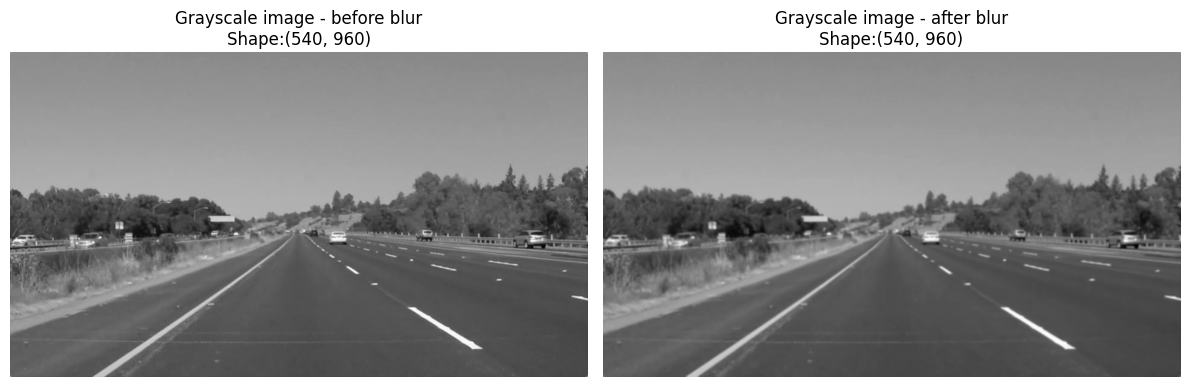

In [ ]:
# Demonstrate Gaussian blur with different kernel sizes
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

kernel_sizes = [1, 3, 5, 7, 9, 11, 15, 21]

for ax, k in zip(axes.flatten(), kernel_sizes):
    if k == 1:
        blurred = gray  # no blur
        title = 'No Blur (k=1)'
    else:
        blurred = cv2.GaussianBlur(gray, (k, k), 0)
        title = f'Gaussian Blur (k={k})'
    
    ax.imshow(blurred, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.suptitle('Effect of Gaussian Blur Kernel Size', fontsize=14)
plt.tight_layout()
plt.show()

print('Observation:')
print('- k=3 or k=5: Good balance - removes noise while keeping edges sharp')
print('- k=7+: Too much blur - edges start to disappear')
print('\nWe chose k=5 for our pipeline.')

# Apply the chosen blur for next steps
blur = cv2.GaussianBlur(gray, (5, 5), 0)

## HLS Color Masking for Lane Detection

Using HLS color space, we can create masks to isolate lane markings:

**White Lane Detection:**
- White lanes have HIGH Lightness (L > 200)
- We threshold the L channel to find bright pixels

**Yellow Lane Detection:**
- Yellow lanes have specific Hue values (around 10-40)
- They also have HIGH Saturation
- We use `cv2.inRange()` to create a mask for yellow pixels

By combining white and yellow masks, we can isolate all lane markings regardless of color.

In [ ]:
# Convert to HLS for color-based lane detection
hls = cv2.cvtColor(img, cv2.COLOR_BGR2HLS)

# White lane mask -> high lightness
# L channel ranges from 0-255, white lanes typically have L > 200
white_mask = cv2.inRange(hls, lowerb=(0, 200, 0), upperb=(255, 255, 255))

# Yellow lane mask -> specific hue + high saturation
# Yellow hue is around 10-40 in OpenCV's HLS (0-180 range)
# High saturation means vivid color (not washed out)
yellow_mask = cv2.inRange(hls, lowerb=(10, 50, 100), upperb=(40, 255, 255))

# Combine both masks using bitwise OR
combined_mask = cv2.bitwise_or(white_mask, yellow_mask)

# Apply mask to the blurred grayscale image
# This keeps only the lane pixels for edge detection
masked_blur = cv2.bitwise_and(blur, combined_mask)

print('White mask: Isolates pixels with high Lightness (L > 200)')
print('Yellow mask: Isolates pixels with yellow Hue (10-40) and high Saturation')
print('Combined mask: Union of white and yellow lanes')

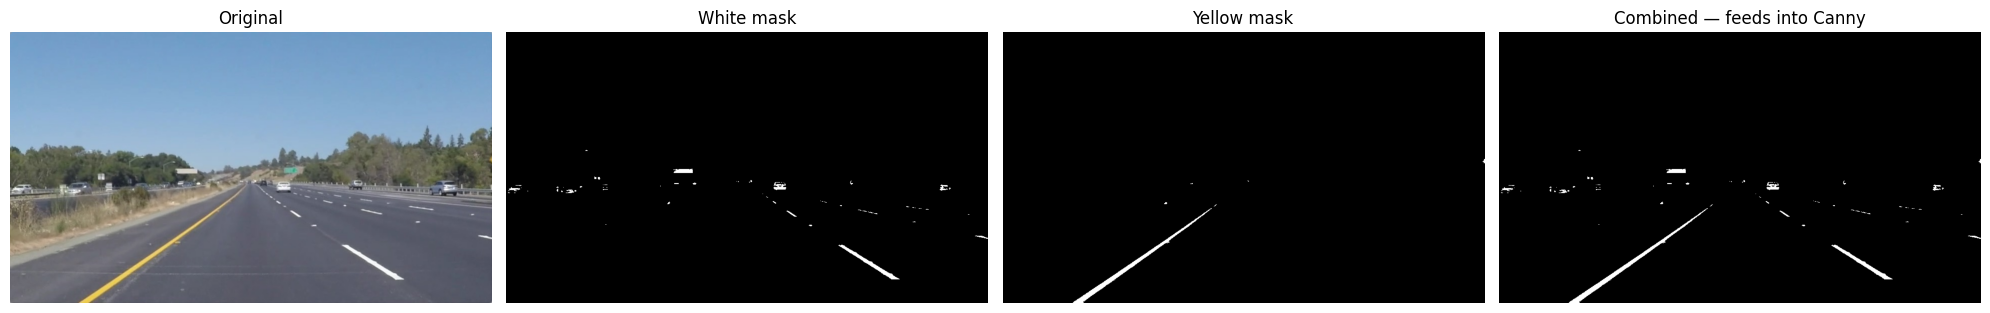

In [ ]:
# Visualize the masking process
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Row 1: Original and individual masks
axes[0, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(white_mask, cmap='gray')
axes[0, 1].set_title('White Lane Mask\n(High Lightness)')
axes[0, 1].axis('off')

axes[0, 2].imshow(yellow_mask, cmap='gray')
axes[0, 2].set_title('Yellow Lane Mask\n(Specific Hue + Saturation)')
axes[0, 2].axis('off')

# Row 2: Combined mask and result
axes[1, 0].imshow(combined_mask, cmap='gray')
axes[1, 0].set_title('Combined Mask\n(White OR Yellow)')
axes[1, 0].axis('off')

axes[1, 1].imshow(blur, cmap='gray')
axes[1, 1].set_title('Blurred Grayscale')
axes[1, 1].axis('off')

axes[1, 2].imshow(masked_blur, cmap='gray')
axes[1, 2].set_title('Masked Result\n(Feeds into Canny Edge Detection)')
axes[1, 2].axis('off')

plt.suptitle('HLS Color Masking for Lane Detection', fontsize=14)
plt.tight_layout()
plt.show()

print('\nThe combined mask isolates both white and yellow lane markings.')
print('This masked image will be used for Canny edge detection in the next step.')

## Canny performance comparison WITH vs WITHOUT BLUR

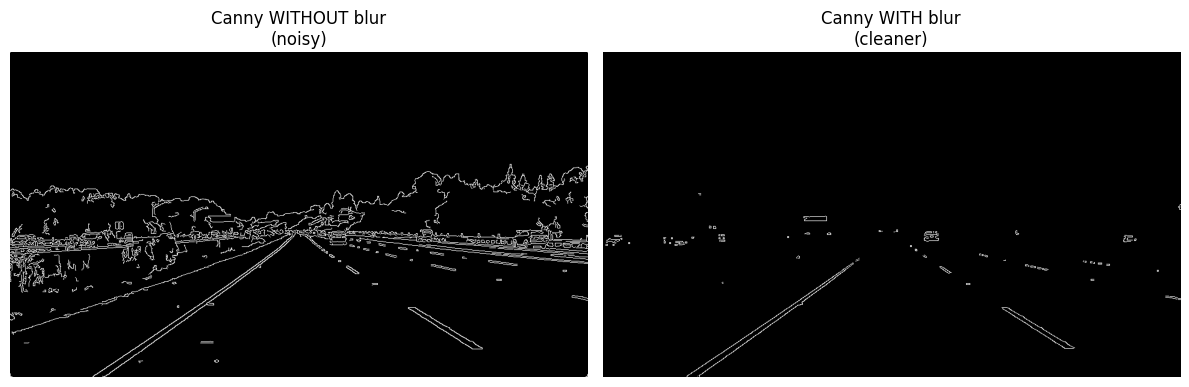

In [ ]:
MIN_VAL_THRESHOLD = 50
MAX_VAL_THRESHOLD = 150

edges_noisy = cv2.Canny(gray, MIN_VAL_THRESHOLD, MAX_VAL_THRESHOLD)
edges_clean = cv2.Canny(masked_blur, MIN_VAL_THRESHOLD, MAX_VAL_THRESHOLD)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(edges_noisy, cmap='gray')
axes[0].set_title("Canny WITHOUT blur\n(noisy)")
axes[0].axis('off')

axes[1].imshow(edges_clean, cmap='gray')
axes[1].set_title("Canny WITH blur\n(cleaner)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Region of Interest

In [ ]:
def region_of_interest(edges):
  height, width = edges.shape
  mask = np.zeros_like(edges)

  # Define trapezoid vertices
  polygon = np.array([[
      (100, height), #bottom-left
      (900, height), #bottom-right
      (width//2+80, height//2+80), #top-right
      (width//2-80, height//2+80), #top-left
  ]], dtype=np.int32)

  cv2.fillPoly(mask, polygon, 255)
  masked = cv2.bitwise_and(edges, mask)
  return masked

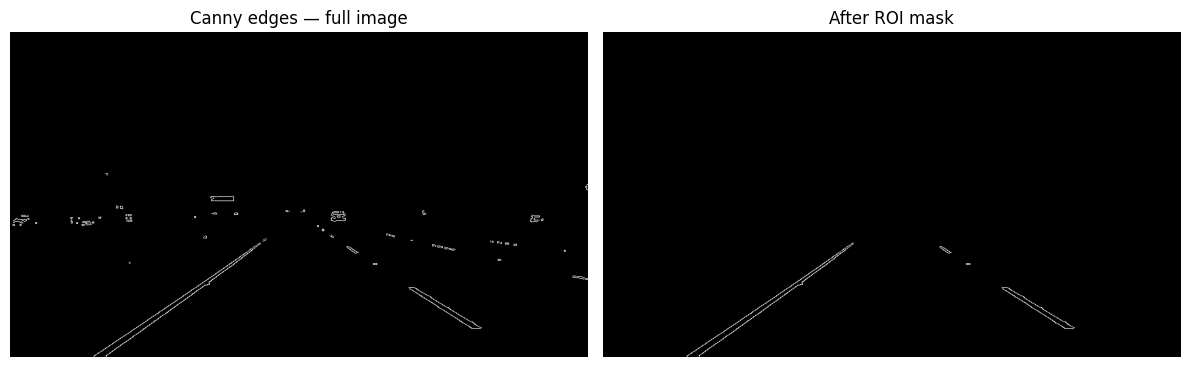

In [ ]:
roi = region_of_interest(edges_clean)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(edges_clean, cmap='gray')
axes[0].set_title("Canny edges — full image")
axes[0].axis('off')

axes[1].imshow(roi, cmap='gray')
axes[1].set_title("After ROI mask")
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Hough Transform

In [ ]:
lines = cv2.HoughLinesP(
    roi,
    rho=1,
    theta=np.pi/180,
    threshold=50,
    minLineLength=40,
    maxLineGap=150
)

print(f"No of lines detected: {lines.shape[0]}")

No of lines detected: 6


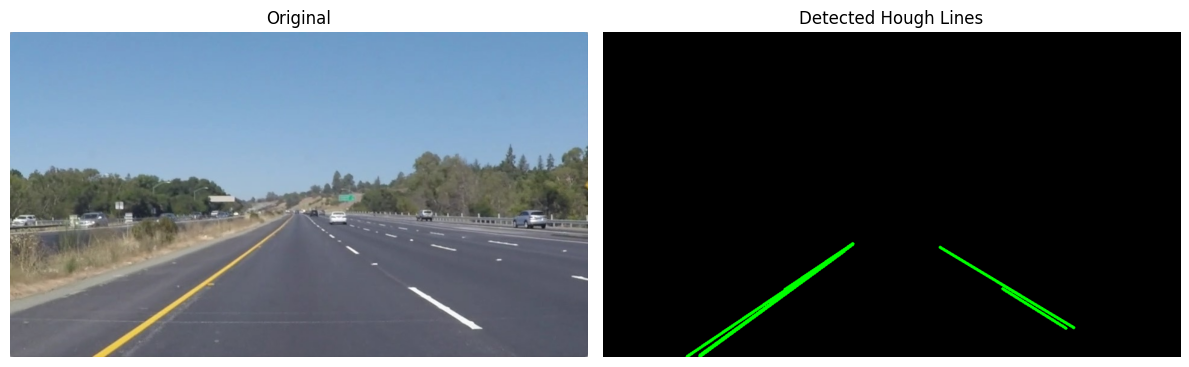

In [ ]:
line_img = np.zeros_like(img)

for line in lines:
  x1, y1, x2, y2 = line[0]
  cv2.line(line_img, (x1,y1), (x2,y2), (0,255,0), 3)

fig, axes = plt.subplots(1, 2, figsize=(12,5))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(line_img)
axes[1].set_title("Detected Hough Lines")
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Slope classification and Simple Averaging

In [ ]:
def average_lines(img, lines):
  left_fit = [] #lines with -ve m
  right_fit = [] #lines with +ve m

  for line in lines:
    x1, y1, x2, y2 = line[0]

    #fitting y=mx+c(1st degree poly) with the two points
    params = np.polyfit((x1,x2), (y1,y2), 1)
    m = params[0]
    c = params[1]

    if m < 0:
      left_fit.append((m,c))
    if m > 0:
      right_fit.append((m,c))

    #Simple averaging
    left_avg = np.average(left_fit, axis=0)
    right_avg = np.average(right_fit, axis=0)

  return left_avg, right_avg

In [ ]:
left_avg, right_avg = average_lines(img, lines)
print(f"Left Lane (Slope, intercept): {left_avg}")
print(f"Right Lane (Slope, intercept): {right_avg}")

Left Lane (Slope, intercept): [ -0.70192246 643.31533343]
Right Lane (Slope, intercept): [ 0.61176919 17.14366698]


## Projection of lines

In [ ]:
def make_points(img, line_params):
  TOP_OF_ROI = 0.6

  height = img.shape[0]
  m, c = line_params

  y1 = height
  y2 = int(height * TOP_OF_ROI)

  x1 = int((y1-c)/m)
  x2 = int((y2-c)/m)

  return (x1, y1, x2, y2)


def draw_lines(img, left_params, right_params):
  output = img.copy()

  left_line = make_points(img, left_avg)
  right_line = make_points(img, right_avg)

  cv2.line(output, (left_line[0], left_line[1]), (left_line[2], left_line[3]), (255,0,0), thickness=2)
  cv2.line(output, (right_line[0], right_line[1]), (right_line[2], right_line[3]), (0,0,255), thickness=2)

  return output

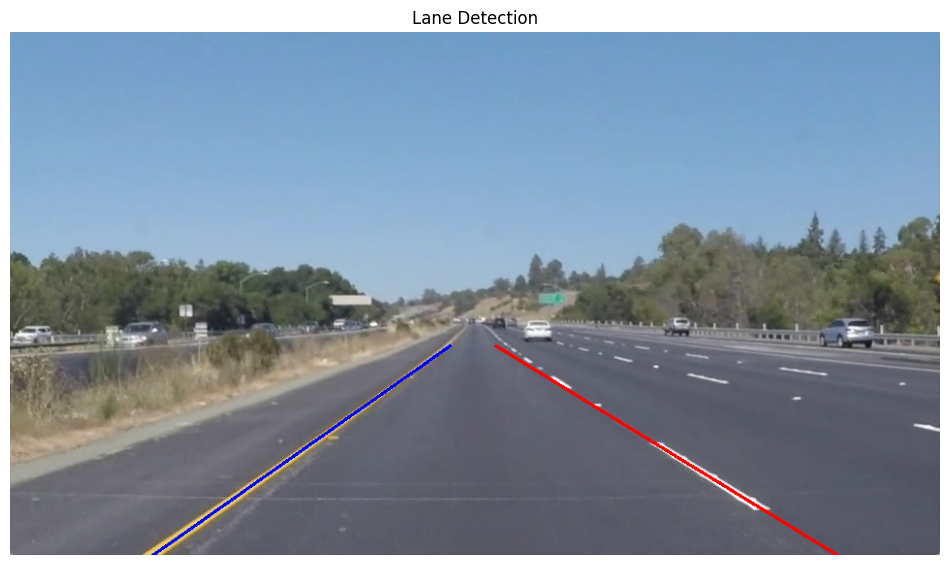

In [ ]:
result = draw_lines(img, left_avg, right_avg)

plt.figure(figsize=(12,8))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Lane Detection")
plt.axis('off')
plt.show()